Environment: velocity

In [ ]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import seaborn
import single_cell_analysis

In [2]:
# Read annotation file
annotation = pyranges.read_gtf("RNA Sequencing Data/mm10 gencode reference/gencode.vM10.primary_assembly.annotation.gtf")
annotation

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,transcript_status,transcript_name,transcript_support_level,tag,havana_transcript,exon_number,exon_id,protein_id,ccdsid,ont
0,GL456210.1,ENSEMBL,gene,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL456210.1,ENSEMBL,transcript,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,NaN,NaN,ENSMUSP00000106995.2,NaN,NaN
2,GL456210.1,ENSEMBL,exon,123791,123905,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
3,GL456210.1,ENSEMBL,CDS,123791,123905,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
4,GL456210.1,ENSEMBL,start_codon,123791,123794,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617650,chrY,ENSEMBL,exon,90838868,90839177,.,-,.,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617651,chrY,ENSEMBL,CDS,90838871,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617652,chrY,ENSEMBL,start_codon,90839174,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617653,chrY,ENSEMBL,stop_codon,90838868,90838871,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN


Description of the Narrowpeak format: https://macs3-project.github.io/MACS/docs/narrowPeak.html

In [3]:
# Function for reading narrowpeak files

def load_narrowpeak(filepath):
    """
    Loads a narrowPeak file into a PyRanges object.
    narrowPeak format is fixed: standard BED 6 columns + 4 signal columns.
    """
    columns = [
        "Chromosome", "Start", "End", "Name", "Score", "Strand",
        "SignalValue", "pValue", "qValue", "Peak"
    ]
    df = pandas.read_csv(filepath, sep=r'\s+', header=None, names=columns)
    return pyranges.PyRanges(df)

In [4]:
# Read narrowpeak files

chipseq_directory = "ChIP Sequencing Data/"
klf4_control_path = chipseq_directory+"KLF4_BFP_merged_peaks.narrowPeak"
klf4_hic2_path = chipseq_directory+"KLF4_Hic2_merged_peaks.narrowPeak"
hic2_path = chipseq_directory+"Ty1_CTer_Hic2_DSG_MKOS48h_peaks.narrowPeak"

klf4_control_peaks = load_narrowpeak(klf4_control_path)
klf4_hic2_peaks = load_narrowpeak(klf4_hic2_path)
hic2_peaks = load_narrowpeak(hic2_path)


In [5]:
# Closest gene method using middle of peak

def closest_gene(peaks, annotation, max_distance=1000000, use_center=True, nb_cpu=1):
    # Filter for protein-coding genes
    genes = annotation[annotation.Feature == "gene"]
    genes_df = genes.as_df()

    # Define the transcription start site based on the strand direction
    positive_strand = genes_df["Strand"] == "+"
    negative_strand = genes_df["Strand"] == "-"
    genes_df.loc[positive_strand, "End"] = genes_df.loc[positive_strand, "Start"]
    genes_df.loc[negative_strand, "Start"] = genes_df.loc[negative_strand, "End"]
    tss_positions = pyranges.PyRanges(genes_df)

    # Find the center of each peak
    peak_center = (peaks.df["Start"] + peaks.df["End"]) / 2.0
    if use_center:
        peaks_df = peaks.as_df()
        peaks_df["Start"] = peak_center
        peaks_df["End"] = peak_center
        peaks = pyranges.PyRanges(peaks_df)

    # Find the closest TSS to each peak
    closest_tss = peaks.nearest(tss_positions, nb_cpu=nb_cpu)

    # Filter distances that are too large
    filtered_indices = (closest_tss.df["Distance"] < max_distance).to_list()
    closest_tss_df = closest_tss.as_df()[filtered_indices]
    peak_center = peak_center[filtered_indices]

    # Check if peak is upstream or downstream
    # If the peak center is exactly at the TSS, the gene will be considered upstream
    is_positive = closest_tss_df["Strand_b"] == "+"
    is_negative = closest_tss_df["Strand_b"] == "-"
    tss_position = closest_tss_df["Start_b"]
    closest_tss_df["Upstream"] = False
    closest_tss_df["Downstream"] = False
    # Upstream peaks
    closest_tss_df.loc[is_positive & (peak_center <= tss_position), "Upstream"] = True
    closest_tss_df.loc[is_negative & (peak_center >= tss_position), "Upstream"] = True
    # Downstream peaks
    closest_tss_df.loc[is_negative & (peak_center < tss_position), "Downstream"] = True
    closest_tss_df.loc[is_positive & (peak_center > tss_position), "Downstream"] = True

    # Get up- and downstream distribution
    upstream_indices = closest_tss_df["Upstream"]
    downstream_indices = closest_tss_df["Downstream"]
    upstream_distribution = closest_tss_df[upstream_indices]["Distance"].to_numpy()
    upstream_distribution.sort()
    downstream_distribution = closest_tss_df[downstream_indices]["Distance"].to_numpy()
    downstream_distribution.sort()

    # Score each peak based on distance distribution
    distances = closest_tss_df["Distance"]
    peak_scores = numpy.zeros_like(distances, dtype=float)
    peak_scores[upstream_indices] = [-numpy.log10((numpy.argmax(upstream_distribution == distance)+1)/len(upstream_distribution)) for distance in distances[upstream_indices]]
    peak_scores[downstream_indices] = [-numpy.log10((numpy.argmax(downstream_distribution == distance)+1)/len(downstream_distribution)) for distance in distances[downstream_indices]]
    closest_tss_df["Peak_score"] = peak_scores

    # Score each gene
    gene_scores = closest_tss_df.groupby("gene_name")["Peak_score"].sum().reset_index()
    gene_scores.index = gene_scores["gene_name"]
    gene_scores = gene_scores.drop(columns="gene_name")
    gene_scores = gene_scores.rename(columns={"Peak_score": "chip_score"})

    # Give genes without peaks a score of 0
    all_genes = genes_df["gene_name"].unique()
    gene_scores = gene_scores.reindex(all_genes, fill_value=0.0)
    gene_scores = gene_scores.sort_values("chip_score", ascending=False)

    return gene_scores

In [55]:
hic2_target_scores = closest_gene(hic2_peaks, annotation, use_center=True, max_distance=1000000)

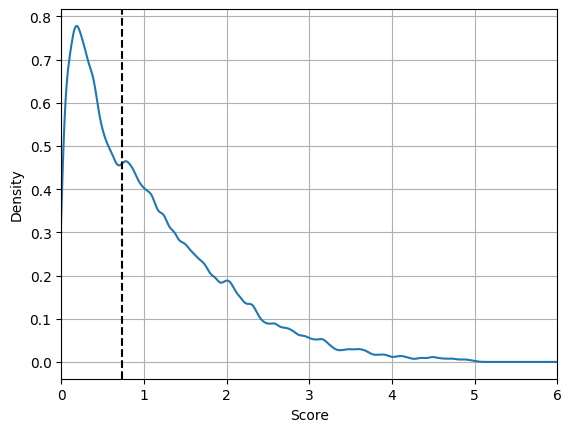

In [56]:
hic2_target_scores.query("chip_score>0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.73
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()

There are two peaks, where the second likely corresponds to true targets. A cutoff at 0.75 was chosen since this is just before the peak, meaning most true positives are found while minimizing unnecessary false positives.

In [57]:
hic2_targets = hic2_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(hic2_targets)} Hic2 targets")

Found 11607 Hic2 targets


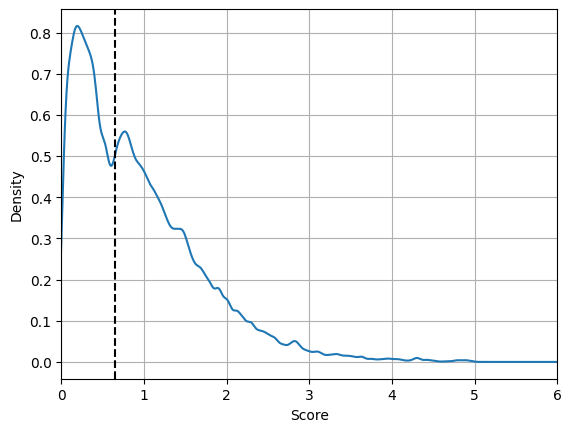

Found 12340 targets for Klf4 with Hic2 overexpression


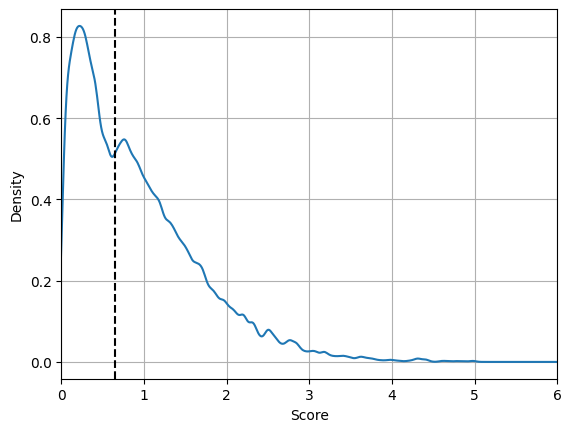

Found 12101 targets for Klf4 without Hic2 overexpression


In [58]:
# Find Klf4 targets with and without Hic2 overexpression

klf4_hic2_target_scores = closest_gene(klf4_hic2_peaks, annotation, use_center=True, max_distance=1000000)
klf4_hic2_target_scores.query("chip_score > 0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.65
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()
klf4_hic2_targets = klf4_hic2_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(klf4_hic2_targets)} targets for Klf4 with Hic2 overexpression")

klf4_control_target_scores = closest_gene(klf4_control_peaks, annotation, use_center=True, max_distance=1000000)
klf4_control_target_scores.query("chip_score > 0 and chip_score < 5")["chip_score"].plot.density(bw_method=0.05)
cutoff=0.65
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(0, 6)
pyplot.show()
klf4_control_targets = klf4_control_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(klf4_control_targets)} targets for Klf4 without Hic2 overexpression")

A cutoff of 0.7 is just before the second peak for both Klf4 experiments.

In [59]:
# Find overlapping binding sites
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
print(f"Found {len(klf4_targets)} overlapping Klf4 targets")

# Shared targets for Hic2 and Klf4
shared_targets = numpy.intersect1d(hic2_targets, klf4_hic2_targets)
print(f"Found {len(shared_targets)} shared targets")

Found 10717 overlapping Klf4 targets
Found 8842 shared targets


In [60]:
# Save targets to disk

base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores.to_csv(f"{base_name}_hic2_scores.csv")
klf4_hic2_target_scores.to_csv(f"{base_name}_klf4_hic2_scores.csv")
klf4_control_target_scores.to_csv(f"{base_name}_klf4_control_scores.csv")

numpy.savetxt(f"{base_name}_hic2_targets.txt", hic2_targets, fmt="%s")
numpy.savetxt(f"{base_name}_klf4_hic2_targets.txt", klf4_hic2_targets, fmt="%s")
numpy.savetxt(f"{base_name}_klf4_control_targets.txt", klf4_control_targets, fmt="%s")

# Get Ovol1 targets with separate ChIP-Seq

Source of ChIP-Seq data: https://www.encodeproject.org/experiments/ENCSR829WBA/

Human annotation from: https://www.gencodegenes.org/human/

Uses the comprehensive gene annotation with primary assembly.

In [11]:
# Read human annotation file
human_annotation = pyranges.read_gtf("ChIP Sequencing Data/gencode.v49.primary_assembly.annotation.gtf")
human_annotation

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,exon_number,exon_id,transcript_support_level,havana_transcript,hgnc_id,havana_gene,ont,protein_id,ccdsid,artif_dupl
0,GL000008.2,HAVANA,gene,83331,200303,.,+,.,ENSG00000296732.1,lncRNA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL000008.2,HAVANA,transcript,83331,200303,.,+,.,ENSG00000296732.1,lncRNA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GL000008.2,HAVANA,exon,83331,83545,.,+,.,ENSG00000296732.1,lncRNA,...,1,ENSE00004078666.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GL000008.2,HAVANA,exon,85566,85625,.,+,.,ENSG00000296732.1,lncRNA,...,2,ENSE00004078618.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GL000008.2,HAVANA,exon,199427,200303,.,+,.,ENSG00000296732.1,lncRNA,...,3,ENSE00004078645.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7762311,chrY,HAVANA,exon,57214349,57214397,.,-,.,ENSG00000292371.1,unprocessed_pseudogene,...,1,ENSE00004015123.1,NA,OTTHUMT00000058841.1,HGNC:37115,OTTHUMG00000022678.1,PGO:0000005,NaN,NaN,NaN
7762312,chrY,HAVANA,exon,57213879,57213964,.,-,.,ENSG00000292371.1,unprocessed_pseudogene,...,2,ENSE00004015124.1,NA,OTTHUMT00000058841.1,HGNC:37115,OTTHUMG00000022678.1,PGO:0000005,NaN,NaN,NaN
7762313,chrY,HAVANA,exon,57213525,57213602,.,-,.,ENSG00000292371.1,unprocessed_pseudogene,...,3,ENSE00004015125.1,NA,OTTHUMT00000058841.1,HGNC:37115,OTTHUMG00000022678.1,PGO:0000005,NaN,NaN,NaN
7762314,chrY,HAVANA,exon,57213203,57213357,.,-,.,ENSG00000292371.1,unprocessed_pseudogene,...,4,ENSE00004015126.1,NA,OTTHUMT00000058841.1,HGNC:37115,OTTHUMG00000022678.1,PGO:0000005,NaN,NaN,NaN


In [9]:
# Read narrowpeak files

chipseq_directory = "ChIP Sequencing Data/"
ovol1_path = chipseq_directory+"Ovol1 chipseq bed.narrowPeak"

ovol1_peaks = load_narrowpeak(ovol1_path)

In [12]:
ovol1_target_scores = closest_gene(ovol1_peaks, human_annotation, use_center=True, max_distance=1000000)

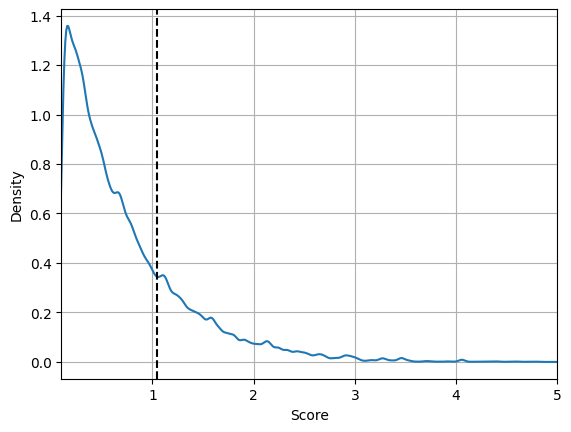

In [49]:
lower_bound = 0.1
upper_bound = 5
ovol1_target_scores.query("chip_score>@lower_bound and chip_score < @upper_bound")["chip_score"].plot.density(bw_method=0.05)
cutoff=1.05
axis = pyplot.gca()
axis.axvline(cutoff, linestyle="dashed", color="black")
axis.grid(True)
axis.set_xlabel("Score")
axis.set_xlim(lower_bound, upper_bound)
pyplot.show()

In [50]:
ovol1_targets = ovol1_target_scores.query("chip_score > @cutoff").index.to_list()
print(f"Found {len(ovol1_targets)} Ovol1 targets")

Found 3027 Ovol1 targets


In [51]:
potential_targets = [s.upper() for s in ['Cdh1', 'Cdh2', 'Gadd45a', 'Gadd45b', 'Hic2', 'Id2', 'Klf4', 'Myc',
       'Ovol1', 'Sgk1', 'Zeb1']]


In [52]:
ovol1_target_scores.loc[potential_targets]

,chip_score
gene_name,
CDH1,0.000000
CDH2,0.449444
GADD45A,0.000000
GADD45B,0.000000
HIC2,0.000000
ID2,0.000000
KLF4,0.000000
MYC,3.458767
OVOL1,1.216375


In [54]:
# Save targets to disk

base_name = "ChIP Sequencing Data/chipseq_targets"

ovol1_target_scores.to_csv(f"{base_name}_hic2_scores.csv")

numpy.savetxt(f"{base_name}_ovol1_targets.txt", ovol1_targets, fmt="%s")

# Comparison to Cellrank data

In [12]:
# Compare to cellrank data

# Read saved objects from Cellrank analysis
working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)

In [14]:
variable_genes = adata.var_names.to_numpy()
stem_cell_drivers = driver_df.sort_values("Dead end_corr", ascending=True).head(100).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Dead end_corr", ascending=False).head(100).index.to_numpy()

In [18]:
# Find which driver genes are targets for Hic2

hic2_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, hic2_targets)
hic2_dead_end_drivers = numpy.intersect1d(dead_end_drivers, hic2_targets)

In [19]:
hic2_stem_cell_drivers

array(['1500009L16Rik', '2810474O19Rik', 'Agtrap', 'Aox3', 'Arrdc4',
       'Atp1b1', 'Calcoco2', 'Car2', 'Ccnb2', 'Col18a1', 'Cox7a1',
       'Dhx16', 'Dnmt3b', 'Fgf4', 'Fgfbp1', 'Fn1', 'Fxyd6', 'Hmgn2',
       'Hspb1', 'Ifitm1', 'Jarid2', 'Klf2', 'Mdk', 'Msh6', 'Mtf2',
       'Mylpf', 'Nodal', 'Phc1', 'Rbpj', 'Rbpms2', 'Rest', 'Rif1',
       'Slc2a3', 'Sparc', 'Syce2', 'Tcea3', 'Tcf7l1', 'Trim71', 'Txnip',
       'Upp1', 'Vangl1', 'Wfdc2', 'Zfp42', 'Zfp462'], dtype=object)

In [20]:
hic2_dead_end_drivers

array(['Aldh3a1', 'Ankrd13b', 'Anxa5', 'Anxa8', 'Avil', 'B2m', 'Bspry',
       'Cbr3', 'Ccnd1', 'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Cisd3',
       'Crip2', 'Ctsb', 'Ctsd', 'Ctsz', 'Dgat2', 'Dkkl1', 'Dmrtc2', 'Dsp',
       'Emp2', 'Emp3', 'Ephx1', 'Fabp5', 'Fkbp11', 'Gatm', 'Gch1', 'Ggh',
       'Gsto1', 'Ifi30', 'Ifrd1', 'Isyna1', 'Kcnn4', 'Krt13', 'Krt8',
       'Lad1', 'Larp1b', 'Lgals7', 'Lmna', 'Lmo1', 'Ly6g6c', 'Mal',
       'Mal2', 'Map1b', 'Marc2', 'Mgst3', 'Misp', 'Myc', 'Nol4l', 'Nradd',
       'Nrip3', 'Nupr1', 'Ovol1', 'Pcolce', 'Pcolce2', 'Perp', 'Pla2g12a',
       'Plec', 'Plek2', 'Prr13', 'Psmb10', 'Ptprv', 'Rac3', 'Rtn4r',
       'S100a14', 'S100a16', 'Sat1', 'Serpinb6c', 'Shisa8', 'Shtn1',
       'Smpdl3a', 'Spink2', 'Spint2', 'Taok3', 'Tlx2', 'Tmem238',
       'Tnfrsf13c', 'Tob1', 'Tppp3', 'Trim47', 'Tubb3', 'Urah', 'Zbtb7c'],
      dtype=object)

In [21]:
# Overlapping Klf4 targets
klf4_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, klf4_targets)
klf4_dead_end_drivers = numpy.intersect1d(dead_end_drivers, klf4_targets)

In [22]:
klf4_stem_cell_drivers

array(['1500009L16Rik', '2810474O19Rik', 'Agtrap', 'Aire', 'Aox3',
       'Arrdc4', 'Atp1b1', 'Calcoco2', 'Car2', 'Ccnb2', 'Cd59a', 'Cotl1',
       'Cox7a1', 'Dnmt3b', 'Eif2s2', 'Fn1', 'Fxyd6', 'H2afv', 'Hmgb2',
       'Hspb1', 'Jarid2', 'Klf2', 'Klhl13', 'Lrpap1', 'Mdk', 'Msh6',
       'Mtf2', 'Nodal', 'Phc1', 'Rbpms2', 'Rest', 'Rif1', 'Slc2a3',
       'Sparc', 'Suz12', 'Syce2', 'Tcea3', 'Tcf7l1', 'Tdgf1', 'Trim71',
       'Txnip', 'Upp1', 'Zfp42', 'Zfp462'], dtype=object)

In [23]:
klf4_dead_end_drivers

array(['Aldh3a1', 'Ankrd13b', 'Anxa5', 'Anxa8', 'B2m', 'Bspry', 'Cbr3',
       'Ccnd1', 'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Chst13', 'Cisd3',
       'Crip2', 'Ctsb', 'Ctsd', 'Ctsz', 'Dgat2', 'Dkkl1', 'Dsp', 'Emp2',
       'Emp3', 'Ephx1', 'Fabp5', 'Gatm', 'Gch1', 'Ggh', 'Gsto1', 'Homer2',
       'Ifi30', 'Isyna1', 'Kcnn4', 'Kiss1r', 'Krt13', 'Krt8', 'Lad1',
       'Larp1b', 'Lgals7', 'Lmna', 'Lmo1', 'Ly6g6c', 'Mal', 'Marc2',
       'Mgst3', 'Misp', 'Myc', 'Nol4l', 'Nradd', 'Nupr1', 'Ovol1',
       'Pcolce', 'Pcolce2', 'Perp', 'Plec', 'Plek2', 'Prr13', 'Ptprv',
       'Rac3', 'Rtn4r', 'S100a1', 'S100a14', 'S100a16', 'Sat1', 'Shisa8',
       'Shtn1', 'Smpdl3a', 'Spink2', 'Spint2', 'Taok3', 'Tlx2',
       'Tnfrsf13c', 'Tob1', 'Tppp3', 'Trim47', 'Tubb3', 'Urah', 'Zbtb7c'],
      dtype=object)

In [24]:
# Shared stem cell drivers
shared_stem_cell_drivers = numpy.intersect1d(hic2_stem_cell_drivers, klf4_stem_cell_drivers)
shared_stem_cell_drivers

array(['1500009L16Rik', '2810474O19Rik', 'Agtrap', 'Aox3', 'Arrdc4',
       'Atp1b1', 'Calcoco2', 'Car2', 'Ccnb2', 'Cox7a1', 'Dnmt3b', 'Fn1',
       'Fxyd6', 'Hspb1', 'Jarid2', 'Klf2', 'Mdk', 'Msh6', 'Mtf2', 'Nodal',
       'Phc1', 'Rbpms2', 'Rest', 'Rif1', 'Slc2a3', 'Sparc', 'Syce2',
       'Tcea3', 'Tcf7l1', 'Trim71', 'Txnip', 'Upp1', 'Zfp42', 'Zfp462'],
      dtype=object)

In [25]:
# Shared dead end drivers
shared_dead_end_drivers = numpy.intersect1d(hic2_dead_end_drivers, klf4_dead_end_drivers)
shared_dead_end_drivers

array(['Aldh3a1', 'Ankrd13b', 'Anxa5', 'Anxa8', 'B2m', 'Bspry', 'Cbr3',
       'Ccnd1', 'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Cisd3', 'Crip2',
       'Ctsb', 'Ctsd', 'Ctsz', 'Dgat2', 'Dkkl1', 'Dsp', 'Emp2', 'Emp3',
       'Ephx1', 'Fabp5', 'Gatm', 'Gch1', 'Ggh', 'Gsto1', 'Ifi30',
       'Isyna1', 'Kcnn4', 'Krt13', 'Krt8', 'Lad1', 'Larp1b', 'Lgals7',
       'Lmna', 'Lmo1', 'Ly6g6c', 'Mal', 'Marc2', 'Mgst3', 'Misp', 'Myc',
       'Nol4l', 'Nradd', 'Nupr1', 'Ovol1', 'Pcolce', 'Pcolce2', 'Perp',
       'Plec', 'Plek2', 'Prr13', 'Ptprv', 'Rac3', 'Rtn4r', 'S100a14',
       'S100a16', 'Sat1', 'Shisa8', 'Shtn1', 'Smpdl3a', 'Spink2',
       'Spint2', 'Taok3', 'Tlx2', 'Tnfrsf13c', 'Tob1', 'Tppp3', 'Trim47',
       'Tubb3', 'Urah', 'Zbtb7c'], dtype=object)

The most interesting shared targets among the dead end drivers are:
- Genes involved in epithelial cell differentiation: KRT17;KRT16;KRT13;OVOL1;CTSB
- Genes involved in epidermal development: CRABP2;FABP5;KLK14;OVOL1

Especially Ovol1 and the keratin genes are relevant. Ovol1 promotes mesenchymal-to-epithelial transition

The most interesting stem cell drivers are:
- Genes regulating epithelial to mesenchymal transition: EPHA4;TCF7L2;SFRP1;MDK;GLIPR2

Mdk is especially interesting as a driver of EMT with interesting expression trends.

# Check which driver targets are transcription factors

Source for list of transcription factors: https://guolab.wchscu.cn/AnimalTFDB#!/download

In [26]:
tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [28]:
# Dead end drivers which are TFs

shared_dead_end_tfs = numpy.intersect1d(shared_dead_end_drivers, tf_array)
driver_df.loc[shared_dead_end_tfs].sort_values("Dead end_corr", ascending=False)

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Tlx2,0.441442,0.000000e+00,0.000000e+00,0.425156,0.457442,-0.441433,0.000000e+00,0.000000e+00,-0.457434,-0.425146
Ovol1,0.420249,0.000000e+00,0.000000e+00,0.403601,0.436620,-0.420250,0.000000e+00,0.000000e+00,-0.436621,-0.403602
Myc,0.344660,2.653811e-270,2.432254e-269,0.326869,0.362206,-0.344658,2.667064e-270,2.444401e-269,-0.362205,-0.326868
Zbtb7c,0.344304,1.059397e-269,9.665180e-269,0.326509,0.361856,-0.344302,1.066928e-269,9.733888e-269,-0.361854,-0.326507


In [30]:
# Hic2 targets instead of shared targets

hic2_dead_end_tfs = numpy.intersect1d(hic2_dead_end_drivers, tf_array)
driver_df.loc[hic2_dead_end_tfs].sort_values("Dead end_corr", ascending=False)

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Tlx2,0.441442,0.000000e+00,0.000000e+00,0.425156,0.457442,-0.441433,0.000000e+00,0.000000e+00,-0.457434,-0.425146
Ovol1,0.420249,0.000000e+00,0.000000e+00,0.403601,0.436620,-0.420250,0.000000e+00,0.000000e+00,-0.436621,-0.403602
Dmrtc2,0.402381,0.000000e+00,0.000000e+00,0.385442,0.419050,-0.402379,0.000000e+00,0.000000e+00,-0.419048,-0.385439
Myc,0.344660,2.653811e-270,2.432254e-269,0.326869,0.362206,-0.344658,2.667064e-270,2.444401e-269,-0.362205,-0.326868
Zbtb7c,0.344304,1.059397e-269,9.665180e-269,0.326509,0.361856,-0.344302,1.066928e-269,9.733888e-269,-0.361854,-0.326507


Ovol1 is the most interesting target. Cdh1 also looks like it could be a Hic2 target, but the narrowpeak file has removed the peak, likely due to a low q-value. The narrowpeak also does not list the peak for Klf4 even though it is a known target of Klf4.

In [31]:
# Stem cell drivers which are TFs

shared_stem_cell_tfs = numpy.intersect1d(shared_stem_cell_drivers, tf_array)
driver_df.loc[shared_stem_cell_tfs].sort_values("Dead end_corr", ascending=True)

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Jarid2,-0.532557,0.0,0.0,-0.546768,-0.518039,0.532545,0.0,0.0,0.518027,0.546756
Zfp42,-0.495528,0.0,0.0,-0.510505,-0.480250,0.495532,0.0,0.0,0.480254,0.510509
Tcf7l1,-0.428266,0.0,0.0,-0.444498,-0.411752,0.428269,0.0,0.0,0.411756,0.444502
Rest,-0.403312,0.0,0.0,-0.419965,-0.386387,0.403315,0.0,0.0,0.386390,0.419968
Klf2,-0.395929,0.0,0.0,-0.412703,-0.378888,0.395928,0.0,0.0,0.378887,0.412702


In [32]:
# Stem cell drivers which are TFs

hic2_stem_cell_tfs = numpy.intersect1d(hic2_stem_cell_drivers, tf_array)
driver_df.loc[hic2_stem_cell_tfs].sort_values("Dead end_corr", ascending=True)

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Jarid2,-0.532557,0.0,0.0,-0.546768,-0.518039,0.532545,0.0,0.0,0.518027,0.546756
Zfp42,-0.495528,0.0,0.0,-0.510505,-0.480250,0.495532,0.0,0.0,0.480254,0.510509
Tcf7l1,-0.428266,0.0,0.0,-0.444498,-0.411752,0.428269,0.0,0.0,0.411756,0.444502
Rbpj,-0.411955,0.0,0.0,-0.428466,-0.395170,0.411944,0.0,0.0,0.395158,0.428455
Rest,-0.403312,0.0,0.0,-0.419965,-0.386387,0.403315,0.0,0.0,0.386390,0.419968
Klf2,-0.395929,0.0,0.0,-0.412703,-0.378888,0.395928,0.0,0.0,0.378887,0.412702


Jarid2 is a strong driver that regulates differentiation of stem cells.

In [33]:
# Hic2 target TFs that are dead end drivers

dead_end_tfs = numpy.intersect1d(hic2_dead_end_drivers, tf_array)
dead_end_tfs

array(['Dmrtc2', 'Myc', 'Ovol1', 'Tlx2', 'Zbtb7c'], dtype=object)

In [34]:
# Hic2 target TFs that are stem cell drivers

stem_cell_tfs = numpy.intersect1d(hic2_stem_cell_drivers, tf_array)
stem_cell_tfs

array(['Jarid2', 'Klf2', 'Rbpj', 'Rest', 'Tcf7l1', 'Zfp42'], dtype=object)

In [35]:
# Find all Hic2 targets that are transcription factors among the variable genes

hic2_target_tfs = numpy.intersect1d(hic2_targets, tf_array)
variable_hic2_target_tfs = numpy.intersect1d(hic2_target_tfs, adata.var_names.to_numpy())
variable_hic2_target_tfs

array(['Arid3a', 'Atf5', 'Barx2', 'Creb3l1', 'Creb3l2', 'Dbp', 'Ddit3',
       'Dmrtc2', 'Egr1', 'Ehf', 'Etv1', 'Etv5', 'Fos', 'Fosb', 'Fosl1',
       'Fosl2', 'Foxp1', 'Foxp2', 'Gata2', 'Gata6', 'Hand1', 'Hic2',
       'Hivep2', 'Hmga2', 'Hmgb3', 'Hopx', 'Hoxa10', 'Hoxa7', 'Hoxb9',
       'Id2', 'Id3', 'Irf1', 'Irx1', 'Irx3', 'Irx5', 'Jarid2', 'Junb',
       'Klf10', 'Klf2', 'Klf4', 'Klf5', 'Klf6', 'Klf7', 'Lhx9', 'Lin28a',
       'Meis2', 'Meox2', 'Msc', 'Mxd1', 'Mybl2', 'Myc', 'Mycn', 'Nfat5',
       'Nfix', 'Nr2f1', 'Nr4a1', 'Ovol1', 'Pax8', 'Peg3', 'Phox2a',
       'Pou5f1', 'Prrx1', 'Prrx2', 'Rbpj', 'Rest', 'Runx1', 'Sall1',
       'Setbp1', 'Smad7', 'Snai2', 'Sox9', 'Tbx3', 'Tcf4', 'Tcf7l1',
       'Tcf7l2', 'Tfap2c', 'Tfcp2l1', 'Tfdp2', 'Tlx2', 'Tlx3', 'Tox',
       'Tsc22d1', 'Tshz1', 'Tshz2', 'Tulp3', 'Tulp4', 'Twist1', 'Twist2',
       'Zbtb20', 'Zbtb7c', 'Zeb2', 'Zfat', 'Zfhx3', 'Zfp296', 'Zfp36l1',
       'Zfp36l2', 'Zfp42', 'Zfp503', 'Zfp710', 'Zim1', 'Zmiz1'],
      dtyp

In [36]:
# Find all shared targets that are transcription factors among the variable genes

shared_target_tfs = numpy.intersect1d(shared_targets, tf_array)
variable_shared_target_tfs = numpy.intersect1d(shared_target_tfs, adata.var_names.to_numpy())
variable_shared_target_tfs

array(['Arid3a', 'Atf5', 'Barx2', 'Creb3l1', 'Creb3l2', 'Dbp', 'Ddit3',
       'Egr1', 'Ehf', 'Etv1', 'Etv5', 'Fos', 'Fosb', 'Fosl1', 'Fosl2',
       'Foxp1', 'Gata2', 'Gata6', 'Hic2', 'Hivep2', 'Hmga2', 'Hoxa7',
       'Hoxb9', 'Id2', 'Id3', 'Irf1', 'Irx1', 'Irx3', 'Irx5', 'Jarid2',
       'Junb', 'Klf10', 'Klf2', 'Klf4', 'Klf5', 'Klf7', 'Lhx9', 'Lin28a',
       'Msc', 'Mxd1', 'Mybl2', 'Myc', 'Mycn', 'Nfat5', 'Nfix', 'Nr2f1',
       'Nr4a1', 'Ovol1', 'Peg3', 'Phox2a', 'Pou5f1', 'Prrx1', 'Rbpj',
       'Rest', 'Sall1', 'Setbp1', 'Smad7', 'Snai2', 'Tbx3', 'Tcf4',
       'Tcf7l1', 'Tcf7l2', 'Tfap2c', 'Tfcp2l1', 'Tfdp2', 'Tlx2', 'Tlx3',
       'Tox', 'Tsc22d1', 'Tshz1', 'Tshz2', 'Tulp3', 'Twist1', 'Twist2',
       'Zbtb20', 'Zbtb7c', 'Zeb2', 'Zfat', 'Zfhx3', 'Zfp296', 'Zfp36l1',
       'Zfp36l2', 'Zfp42', 'Zfp503', 'Zfp710', 'Zim1', 'Zmiz1'],
      dtype=object)

In [39]:
# Rank all Hic2 targets by correlation with cell fates

# Top dead end drivers
driver_df.loc[variable_hic2_target_tfs].sort_values("Dead end_corr", ascending=False).query("`Dead end_corr` > 0")

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Tlx2,0.441442,0.000000e+00,0.000000e+00,0.425156,0.457442,-0.441433,0.000000e+00,0.000000e+00,-0.457434,-0.425146
Ovol1,0.420249,0.000000e+00,0.000000e+00,0.403601,0.436620,-0.420250,0.000000e+00,0.000000e+00,-0.436621,-0.403602
Dmrtc2,0.402381,0.000000e+00,0.000000e+00,0.385442,0.419050,-0.402379,0.000000e+00,0.000000e+00,-0.419048,-0.385439
Myc,0.344660,2.653811e-270,2.432254e-269,0.326869,0.362206,-0.344658,2.667064e-270,2.444401e-269,-0.362205,-0.326868
Zbtb7c,0.344304,1.059397e-269,9.665180e-269,0.326509,0.361856,-0.344302,1.066928e-269,9.733888e-269,-0.361854,-0.326507
Phox2a,0.303210,1.262186e-205,8.696024e-205,0.284892,0.321306,-0.303209,1.263982e-205,8.708400e-205,-0.321305,-0.284892
Foxp1,0.301531,3.142391e-203,2.150170e-202,0.283193,0.319647,-0.301511,3.351202e-203,2.293049e-202,-0.319628,-0.283174
Hmgb3,0.249319,8.590394e-137,4.269554e-136,0.230422,0.268029,-0.249313,8.716927e-137,4.332443e-136,-0.268023,-0.230416
Runx1,0.247741,5.104603e-135,2.505896e-134,0.228829,0.266467,-0.247743,5.083585e-135,2.495578e-134,-0.266469,-0.228830


In [41]:
# Top stem cell drivers
driver_df.loc[variable_hic2_target_tfs].sort_values("Dead end_corr", ascending=True).query("`Dead end_corr` < 0")

,Dead end_corr,Dead end_pval,Dead end_qval,Dead end_ci_low,Dead end_ci_high,Stem cell_corr,Stem cell_pval,Stem cell_qval,Stem cell_ci_low,Stem cell_ci_high
gene_names,,,,,,,,,,
Jarid2,-0.532557,0.000000e+00,0.000000e+00,-0.546768,-0.518039,0.532545,0.000000e+00,0.000000e+00,0.518027,0.546756
Zfp42,-0.495528,0.000000e+00,0.000000e+00,-0.510505,-0.480250,0.495532,0.000000e+00,0.000000e+00,0.480254,0.510509
Tcf7l1,-0.428266,0.000000e+00,0.000000e+00,-0.444498,-0.411752,0.428269,0.000000e+00,0.000000e+00,0.411756,0.444502
Rbpj,-0.411955,0.000000e+00,0.000000e+00,-0.428466,-0.395170,0.411944,0.000000e+00,0.000000e+00,0.395158,0.428455
Rest,-0.403312,0.000000e+00,0.000000e+00,-0.419965,-0.386387,0.403315,0.000000e+00,0.000000e+00,0.386390,0.419968
Klf2,-0.395929,0.000000e+00,0.000000e+00,-0.412703,-0.378888,0.395928,0.000000e+00,0.000000e+00,0.378887,0.412702
Mycn,-0.350772,8.853933e-281,8.587455e-280,-0.368232,-0.333065,0.350773,8.827681e-281,8.561994e-280,0.333066,0.368232
Etv5,-0.334272,4.562567e-253,3.814229e-252,-0.351962,-0.316343,0.334266,4.665801e-253,3.884279e-252,0.316337,0.351956
Etv1,-0.318996,5.508220e-229,4.232855e-228,-0.336890,-0.300871,0.318996,5.512030e-229,4.235783e-228,0.300871,0.336890


## Trends of transcription factors

In [42]:
# Define colors for all three groups

group_colors = [
    "#cbc9ca",
    "#0a652c",
    "#da2e24",
    "#3180bd",
]

adata.uns["group_colors"] = group_colors

control_indices = adata.obs["group"] == "control"
hic2_indices = adata.obs["group"] == "Hic2"
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

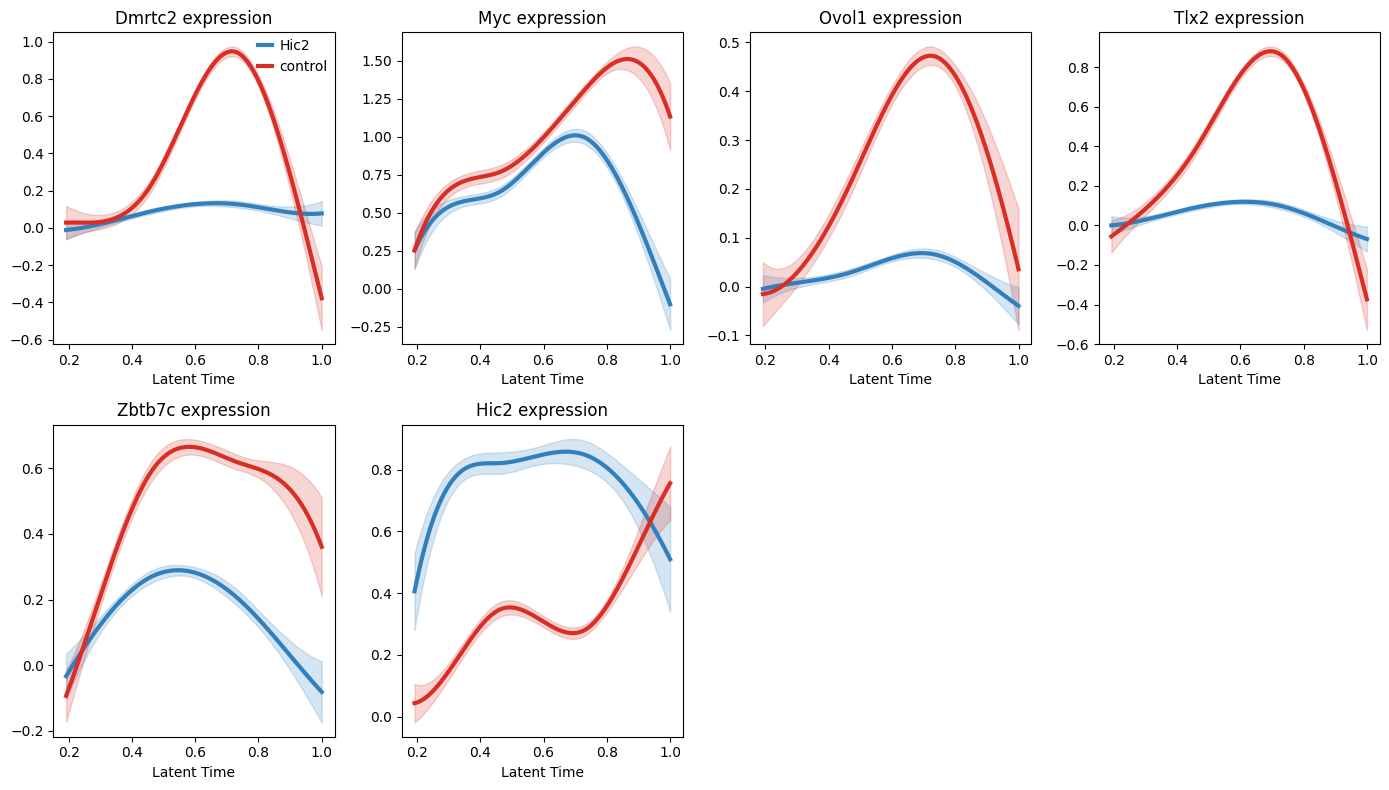

In [46]:
# Expression of dead end drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata, 
    list(dead_end_tfs)+ ["Hic2"], 
    group_key="group",
    groups=["Hic2", "control"]
)

Ovol1, Cdh1, Tlx2, Zbtb7c and Hmgb3 have the largest differences in expression between the groups. Once again, Ovol1 looks most promising. Hoxa7 does not look like a driver since it changes late in the process where some control cells reach the dead end. Myc is repressed by Ovol1, but is also a target of Hic2. If Hic2 downregulates Myc, Hic2 reprogramming could benefit from more Myc OX.

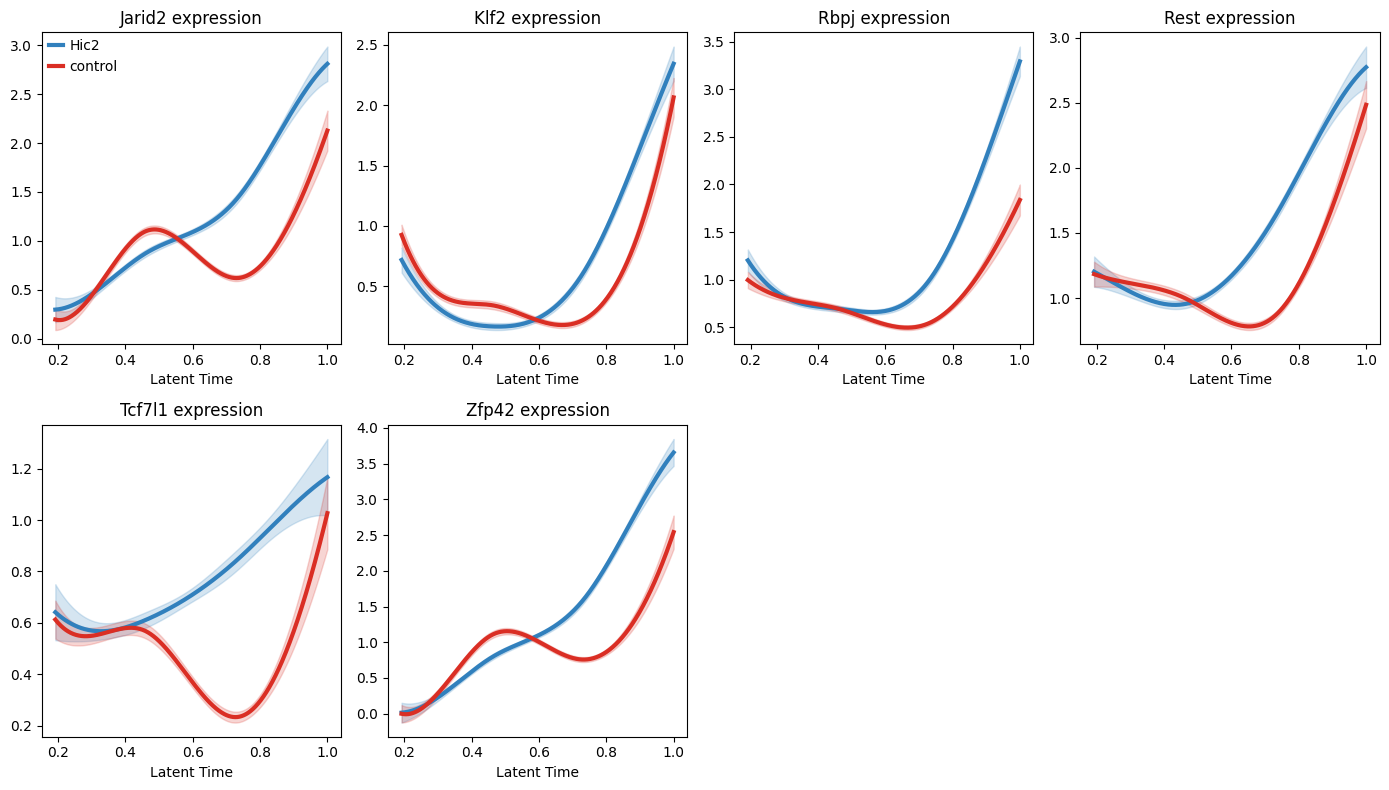

In [47]:
# Expression of reprogramming drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    stem_cell_tfs,
    group_key="group",
    groups=["Hic2", "control"]
)

Jarid2, Tcf7l1, Rest and Tcf7l2 have the most interesting trends, but unlike the dead end drivers many only have differential expression later in during the process.

To do: Look at changes in transcription factor activity instead of mRNA levels. Below is a start for this

In [58]:
# Use consensus network instead that also uses ChipSeq and motif data. Has Jarid in addition to the ones in TF_Perturbations_Followed_by_Expression,
# but gives values that do not work with Cellrank's gene_trends function
import decoupler
net = decoupler.op.collectri(organism='mouse')

# Fix Ovol1 direction
modified_collectri = net
modified_collectri.loc[modified_collectri["source"] == "Ovol1", "weight"] = -1.0
modified_collectri.loc[(modified_collectri["source"] == "Ovol1") & (modified_collectri["target"] == "Ovol1"), "weight"] = 0

In [59]:
# Convert 'TARGET_GENE' -> 'Target_gene'
# net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
# net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
decoupler.mt.ulm(adata, net=modified_collectri, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-03-12 14:41:22 | [INFO] ulm - Running ulm
2026-03-12 14:41:22 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-03-12 14:41:22 | [INFO] Network adjacency matrix has 1118 unique features and 459 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-03-12 14:41:22 | [INFO] ulm - fitting 459 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-03-12 14:41:23 | [INFO] ulm - adjusting p-values by FDR
2026-03-12 14:41:23 | [INFO] ulm - done


In [52]:
from importlib import reload

single_cell_analysis = reload(single_cell_analysis)

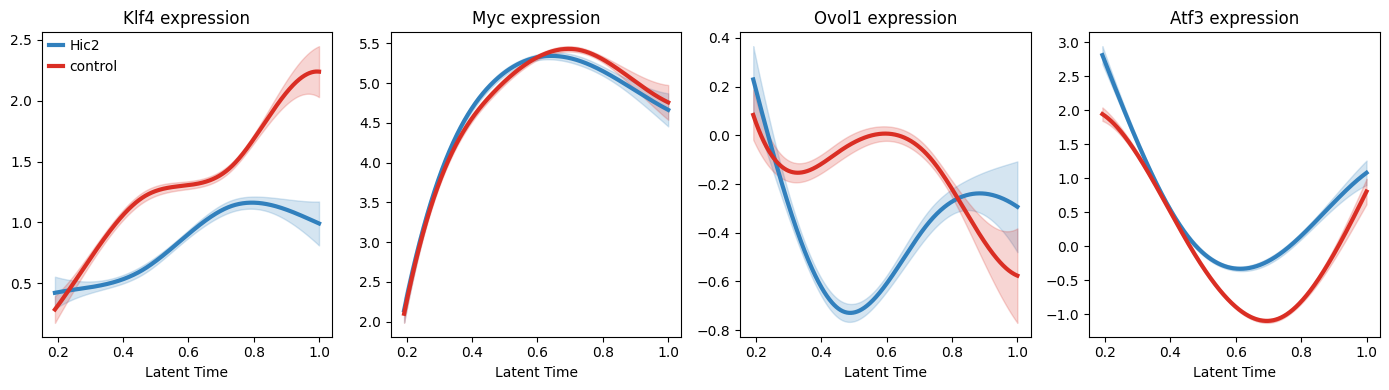

In [62]:
# Activity of interesting genes

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc", "Ovol1", "Atf3"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

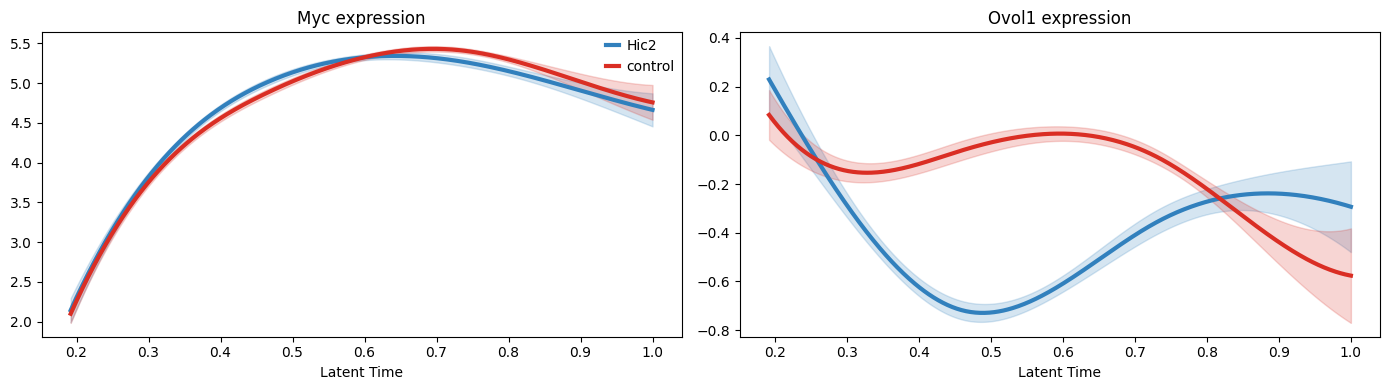

In [63]:
# Activity of dead end TFs

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Ovol1 activity is surprisingly higher in Hic2 cells, despite much lower expression.

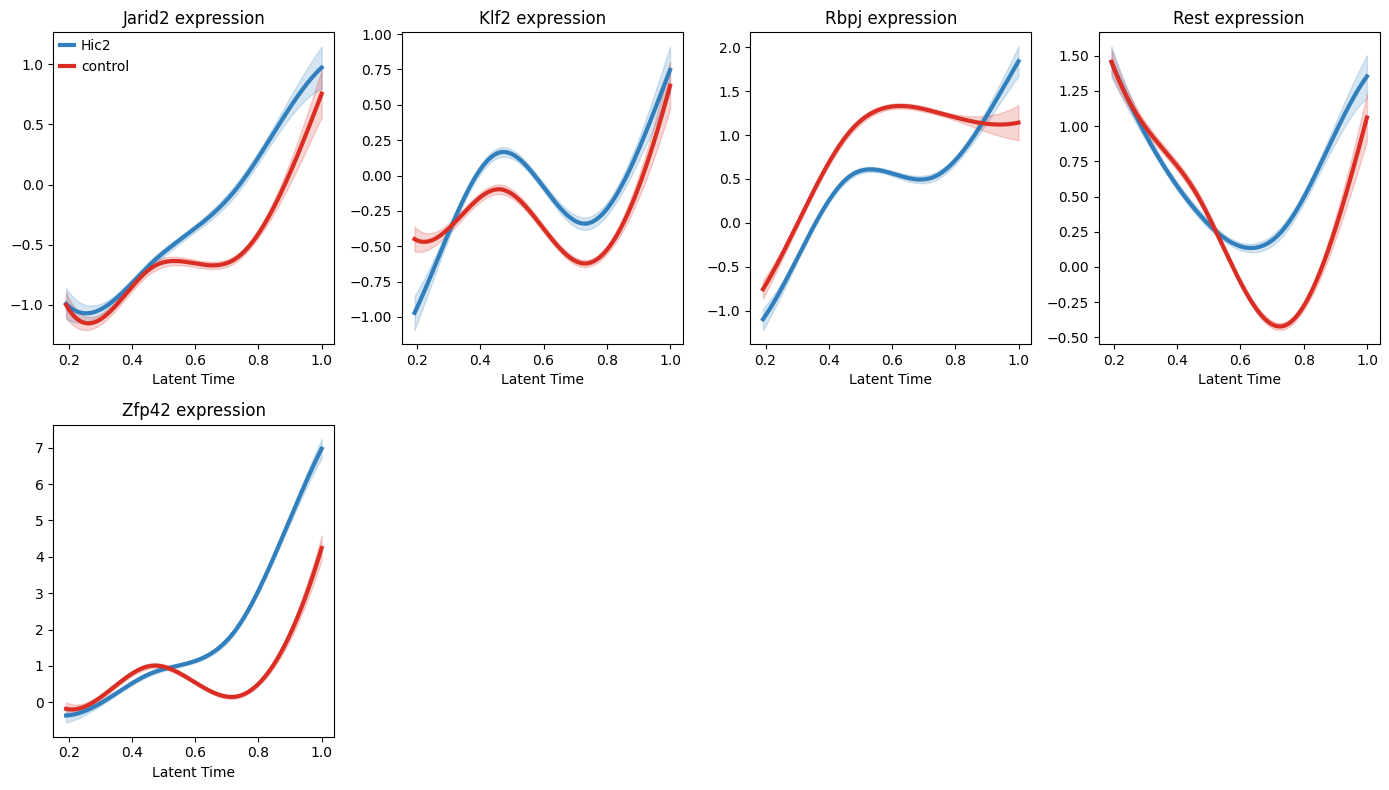

In [64]:
# Activity of reprogramming drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Jarid2 and Zfp42 activities follow almost the exact same trends as their mRNA levels. They are similar until Hic2 and control cells start to take different trajectories. Rest has similar trends as its mRNA expression.

In [65]:
def load_enrichr_as_network(library_name):
    # 1. Download the library using GSEApy
    # Returns a dictionary: {'Term_Name': ['GeneA', 'GeneB', ...]}
    gs_dict = gseapy.get_library(name=library_name, organism='Mouse')
    
    network_list = []
    
    for term, genes in gs_dict.items():
        # The term usually looks like "KLF4 DOWN ..." or "KLF4_MOUSE_..."
        # We need to extract the TF name. 
        # CAUTION: This splitting depends on the specific naming convention of the library
        # For 'TF_Perturbations_Followed_by_Expression', format is often "TF_Perturbation_Direction"
        # We will attempt to grab the first word as the TF name
        if library_name in {"PerturbSeq_ReplogleK562", "PerturbSeq_ReplogleRPE1"}:
            tf_name = term.split()[1].upper()
        else:
            tf_name = term.split()[0].split('_')[0].upper() 
        
        for gene in genes:
            network_list.append({
                'source': tf_name,
                'target': gene,
                'weight': 1.0,      # We assume all targets are equal
                'collection': term  # Keep original term just in case
            })
            
    return pandas.DataFrame(network_list)

In [67]:
# Load another library
perturbation_network = load_enrichr_as_network('TF_Perturbations_Followed_by_Expression') # Has the most genes because it is a collection

2026-03-12 14:44:32 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-12 14:44:32 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.TF_Perturbations_Followed_by_Expression.gmt, use local file


In [ ]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
decoupler.mt.ulm(adata, net=net, verbose=True)

2026-03-12 14:45:02 | [INFO] ulm - Running ulm
2026-03-12 14:45:02 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-03-12 14:45:02 | [INFO] Network adjacency matrix has 1744 unique features and 342 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-03-12 14:45:02 | [INFO] ulm - fitting 342 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-03-12 14:45:03 | [INFO] ulm - adjusting p-values by FDR
2026-03-12 14:45:03 | [INFO] ulm - done


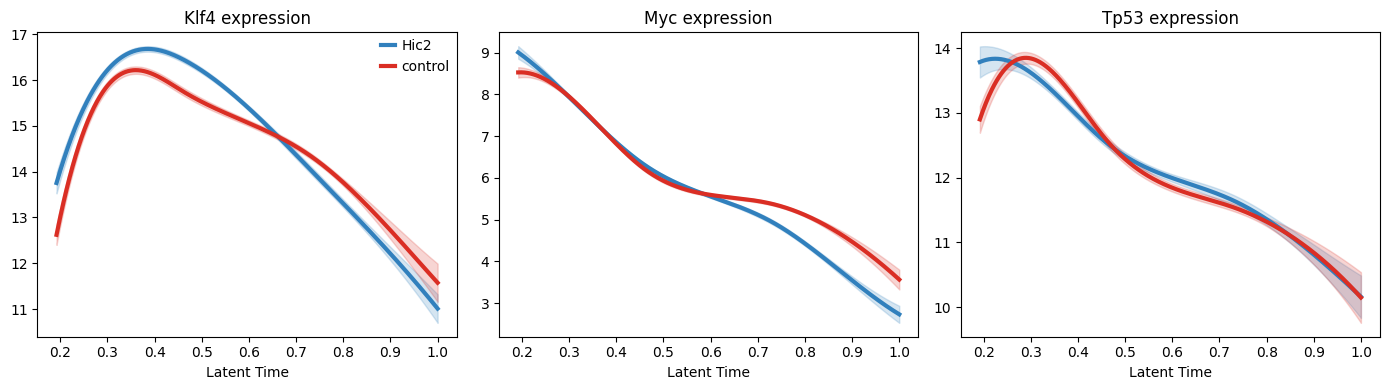

In [70]:
# Activity of interesting genes

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc", "Tp53"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

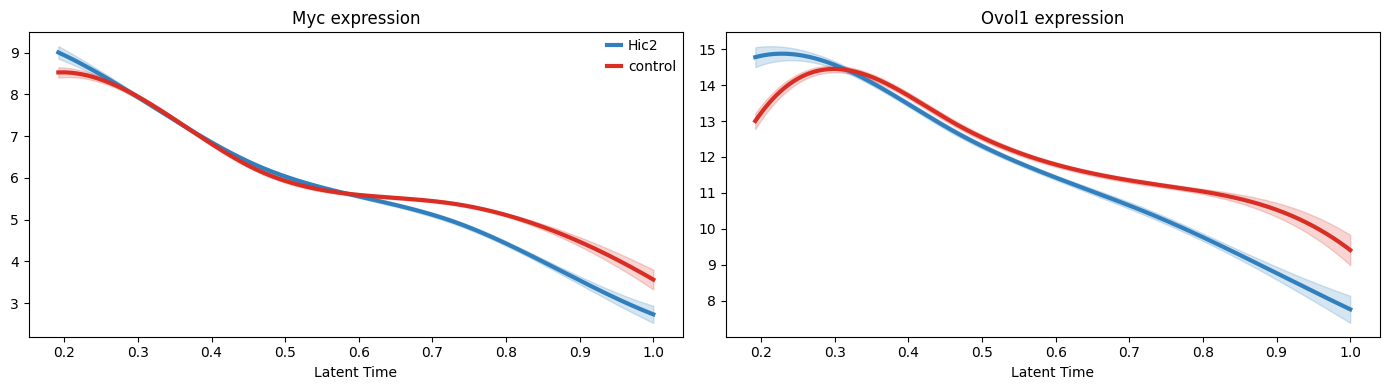

In [71]:
# Activity of dead end TFs

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

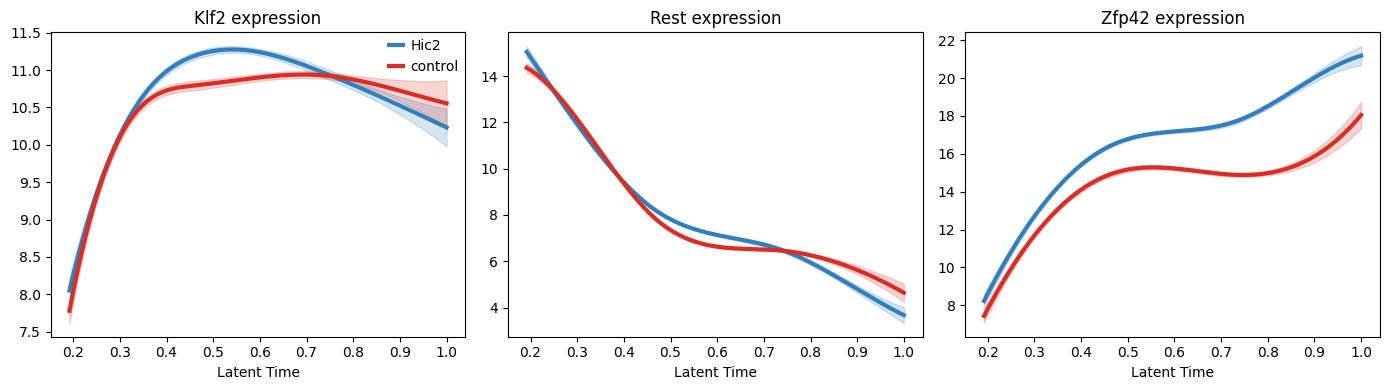

In [72]:
# Activity of reprogramming drivers

single_cell_analysis.plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

In [82]:
# Cellrank gene trends for dead end


def plot_tf_trends(adata, tfs, time_key, model=None, group_key="group"):
    """
    Plots Decoupler TF activity scores using CellRank's gene_trends.
    """
    # Extract the ULM scores (Cell x TF matrix)
    activity_matrix = adata.obsm['score_ulm'].copy()
    
    # Create a new temporary AnnData object
    # The 'variables' (var) of this object are the TFs, not genes
    tf_adata = scanpy.AnnData(activity_matrix)
    tf_adata.obs = adata.obs.copy()  # Copy metadata (pseudotime, clusters)
    tf_adata.obsm = adata.obsm.copy() # Copy embeddings (UMAP) and lineage probs
    tf_adata.uns = adata.uns.copy()   # Copy CellRank lineage colors/names
    
    # Setup the CellRank model if not provided
    if model is None:
        model = cellrank.models.GAMR(tf_adata)
        
    # Plot using the standard function
    cellrank.pl.gene_trends(
    tf_adata,
    model=model,
    genes=tfs,
    data_key="X",
    same_plot=True,
    lineages = ["Stem cell", "Dead end"],
    ncols=4,
    time_key=time_key,
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)

  0%|          | 0/3 [00:00<?, ?gene/s]

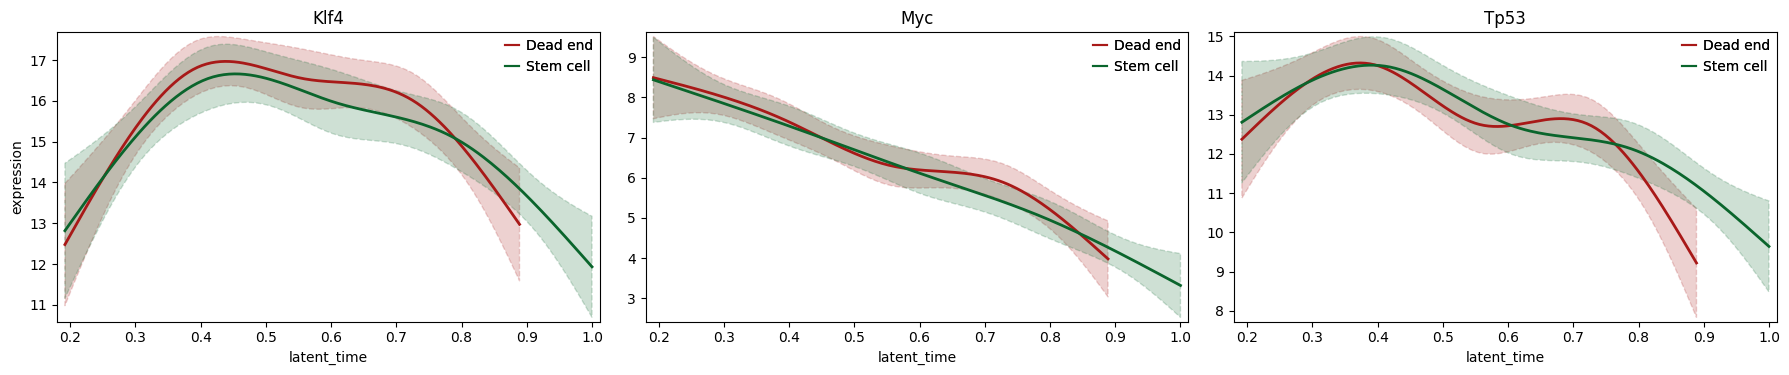

In [83]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(["Klf4", "Myc", "Tp53"], adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/2 [00:00<?, ?gene/s]

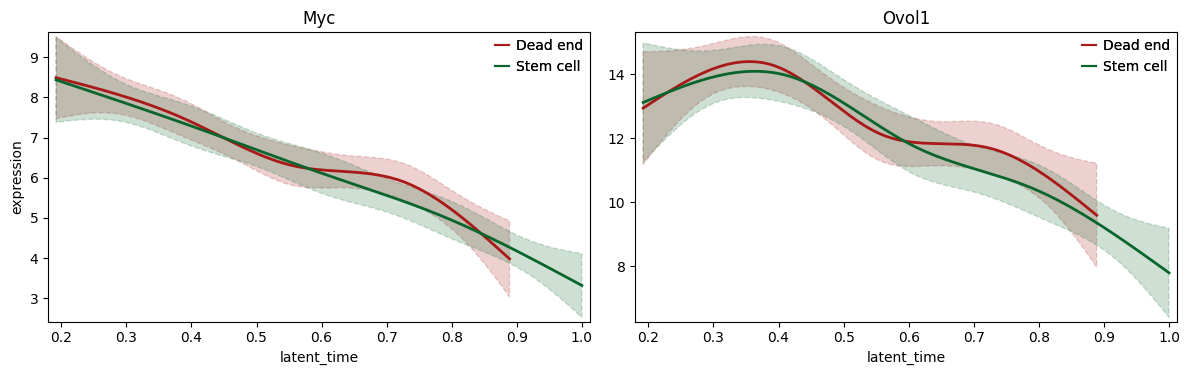

In [84]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/3 [00:00<?, ?gene/s]

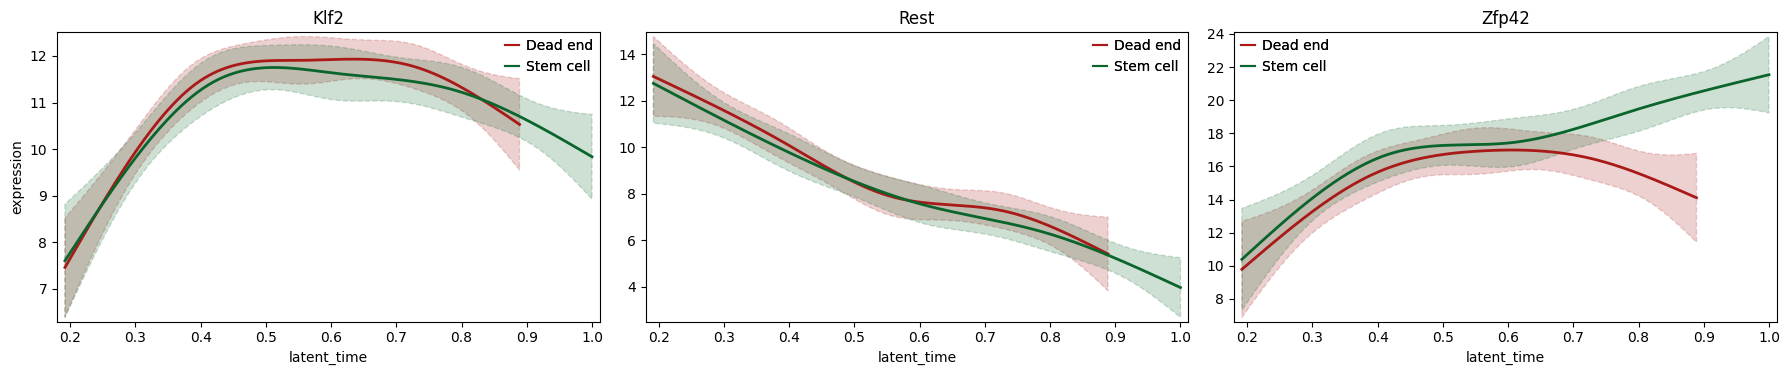

In [85]:
# Cellrank gene trends for stem cells

plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time' # or 'dpt_pseudotime'
)

Zfp42 activity is interesting, as it increases in the mESC cells. The other genes do not look like clear reprogramming drivers.

# Conclusions

The most important target of Hic2 is Ovol1. It downregulates c-Myc (https://www.nature.com/articles/modpathol2016169) and inhibits the epithelial to mesenchymal transition by degrading the TGF-β receptor type 1 while promoting mesenchymal-to-epithelial transition (https://www.nature.com/articles/s41392-022-00944-w).